In [63]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql import dataframe
from pyspark.sql.types import StructType, StructField, DoubleType
from sklearn import metrics
import time
import sys
import logging
import uuid
import os
import shutil
import json
import argparse
import pytorch_model_summary as pms

## Load test data

In [2]:
config = {
    "model_type": "skip",
    "input_shape": 4,
    "amplitude_shape": 36,
    "data_dir": "/scratch/akula.ha/dataset",
    "seed": 42,
    "var_y": [
        "y5", "y6", "y13", "y14"
    ],
    "activation": "leaky_relu",
    "width": 32,
    "depth": 16,
    "skip_block_layers": 1,
    "beta": 0,
    "alpha": 0,
    "normal_scaled": False,
    "lr_decay_type": "exp",
    "initial_lr": 0.001,
    "final_lr": 1e-06,
    "decay_steps": 60000,
    "train-sample-size": 1000000,
    "validate-sample-size": 500000,
    "test-sample-size": 500000,
    "use_MC_sample": False,
    "batch_size": 512,
    "steps_per_epoch": 2000,
    "early_stopping_start_epoch": 50,
    "patience": 30,
    "monitor": "val_mse",
    "loss": "mse",
    "gradient_clipping": True,
    "verbose": 1,
    "base_directory": "../models/",
    "epochs": 300,
    "model-uuid": "55960c0a",
    "start_time": "2024-07-24 15:51:20 -0400",
    "device": "cuda",
    "directory": "../models/skip-torch-4D-y5-55960c0a",
    "train-samples-used": 5,
    "validate-samples-used": 5,
    "test-samples-used": 5,
    "n_targets": 1,
    "scaling": {},
    "trainable_parameters": 49953,
    "non_trainable_parameters": 0,
    "total_parameters": 49953,
    "final_decayed_lr": 2.9603839189656035e-06,
    "final_validation_r2": 99.65285361142811,
    "final_validation_loss": 0.04399269253775254,
    "last_epoch": 126,
    "n_training_epochs": 96,
    "fit_time": "1:34:31",
    "test_metrics": {
        "r2": {
            "y5": 43.456519728103956,
            "model": 99.67026049377984
        },
        "abs_score": {
            "y5": 99.16697097158196,
            "model": 94.92863425723608
        }
    },
    "end_time": "2024-07-24 17:28:10 -0400"
}

In [4]:
def init_torch(config):
    ''' function for initializing the seeds
        arguments:
            config: the configuration file
    '''
    gen = torch.manual_seed(config['seed'])
    torch.set_default_dtype(torch.float64)
    
    device = get_device()

    if device.type == 'cpu':
        torch.set_num_threads(64)
        # torch.set_num_interop_threads(1)

    logging.info(f' torch is using {device}')
    
    return device

In [5]:
def get_device():
    ''' function to get the device the NN is running on, CPU or GPU
    '''
    if torch.cuda.is_available():
        device = torch.device("cuda:0")
    else: 
        device = torch.device("cpu")
        
    return device

In [6]:
device = init_torch(config)

In [7]:
import re

In [8]:
def load_data(config):
    """ Load the data using pyspark
        arguments:
            config: the configuration file
        returns:
            df['train']: the training dataframe
            df['validate']: the validation data set
            df['test']: the testing data set
            spark: the spark session
    """
    
    # Spark session and configuration
    logging.info(' creating Spark session')
    spark = (SparkSession.builder.master("local[48]")
             .config('spark.executor.instances', 16)
             .config('spark.executor.cores', 16)
             .config('spark.executor.memory', '10g')
             .config('spark.driver.memory', '15g')
             .config('spark.memory.offHeap.enabled', True)
             .config('spark.memory.offHeap.size', '20g')
             .config('spark.dirver.maxResultSize', '20g')
             .config('spark.debug.maxToStringFields', 100)
             .appName("amp.hell").getOrCreate())

    # Enable Arrow-based columnar data 
    spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")
    spark.conf.set(
        "spark.sql.execution.arrow.pyspark.fallback.enabled", "true"
    )
    logging.info(' Spark initialized')
    
    # read the data into a spark frame
    start = time.time()
    path = config['data_dir']
    if path[-1] != '/':
        path = path + '/'
    input_var = ['x'+str(i+1) for i in range(config['input_shape'])]
    target_var = ['y'+str(i+1) for i in range(config['amplitude_shape'])]

    header = input_var + target_var
    schema = StructType([StructField(header[i], DoubleType(), True) for i in range(config['input_shape']+config['amplitude_shape'])])

    df = {}
    df['train'] = spark.read.options(delimiter=',').schema(schema).format("csv").load(path+'train/*.csv.*', header='true')
    
    
    if config['var_y'] == 'all': config['var_y'] = df['train'].columns[config['input_shape']:]
    
    
    if config['use_MC_sample']:
        mc_suffix = '_mc'
    else:
        mc_suffix = ''
    df['validate'] = spark.read.options(delimiter=',').schema(schema).format("csv").load(path+'validate'+mc_suffix+'/*.csv.*', header='true')
    df['test'] = spark.read.options(delimiter=',').schema(schema).format("csv").load(path+'test'+mc_suffix+'/*.csv.*', header='true')

    logging.info(' data loaded into Spark session in {:.3f} seconds'.format(time.time() - start))
    
    # transfer the data to a pandas dataframe
    start = time.time()
    train_sample = min(config['train-sample-size'], df['train'].count())
    validate_sample = min(config['validate-sample-size'], df['validate'].count())
    test_sample = min(config['test-sample-size'], df['test'].count())
    
    ########################################################################
    # Assuming config['var_y'] is the list
    operators = ['+', '-', '*', '/']

    # List of items with operators
    with_operator = [item for item in config['var_y'] if any(op in item for op in operators)]
    print(with_operator)
    # List of items without operators
    without_operator = [item for item in config['var_y'] if all(op not in item for op in operators)]
    print(without_operator)
    
    # Split the items with operators into individual components
    split_items = [subitem for item in with_operator for subitem in re.split(r'\+|\-|\*|\/', item)]

    # Combine the split items with the items without operators
    combined_list = without_operator + split_items

    # Remove duplicates to get a unique list
    unique_list = list(set(combined_list))

    # Sort the list if you want it in a specific order (optional)
    unique_list.sort()
    
    ########################################################################
    
    df['train'] = df['train'].select(*input_var, *unique_list).limit(train_sample).toPandas() 
    df['validate'] = df['validate'].select(*input_var, *unique_list).limit(validate_sample).toPandas()
    df['test'] = df['test'].select(*input_var, *unique_list).limit(test_sample).toPandas()
    
    # Step 1: Perform the operations
    for key in ['train', 'validate', 'test']:
        for expr in config['var_y']:
            if any(op in expr for op in ['+', '-', '*', '/']):
                # Split the expression into individual components and operator
                components = re.split(r'(\+|\-|\*|\/)', expr)

                # Evaluate the expression and create a new column
                if len(components) == 3:  # This should match the pattern "y1 + y3"
                    col1, operator, col2 = components

                    if operator == '+':
                        df[key][expr] = df[key][col1] + df[key][col2]
                    elif operator == '-':
                        df[key][expr] = df[key][col1] - df[key][col2]
                    elif operator == '*':
                        df[key][expr] = df[key][col1] * df[key][col2]
                    elif operator == '/':
                        df[key][expr] = df[key][col1] / df[key][col2]

    # Filter split_items to keep only those that are also in without_operator
    filtered_items = [item for item in split_items if item not in without_operator]

    # Drop the filtered items from the DataFrames
    for key in ['train', 'validate', 'test']:
        df[key] = df[key].drop(columns=filtered_items, errors='ignore')

    
    logging.info(' training data shape: {} x {}'.format(df['train'].shape[0], df['train'].shape[1]))
    logging.info(' validation data shape: {} x {}'.format(df['validate'].shape[0], df['validate'].shape[1]))
    logging.info(' testing data shape: {} x {}'.format(df['test'].shape[0], df['test'].shape[1]))
    
    config['train-samples-used'] = df['train'].shape[1]
    config['validate-samples-used'] = df['validate'].shape[1]
    config['test-samples-used'] = df['test'].shape[1]

    logging.info(' data loaded into pandas dataframe in {:.3f} seconds'.format(time.time() - start))
    
    logger = spark._jvm.org.apache.log4j
    logging.getLogger("py4j.clientserver").setLevel(logging.WARN)

    return df, spark


In [9]:
data_df, spark = load_data(config)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/09/06 14:59:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


[]
['y5', 'y6', 'y13', 'y14']


In [10]:
data_df

{'train':                   x1        x2        x3        x4         y13         y14  \
 0       5.308962e-08  0.309913  0.050721  0.629043 -153.141005  158.817536   
 1       3.505005e-07  0.281701  0.997791  0.482102 -185.727786  194.600993   
 2       4.480013e-07  0.609822  0.147178  0.852029  -54.793053   52.993422   
 3       6.298025e-07  0.258704  0.408208  0.122103 -174.828685  182.689924   
 4       1.014703e-06  0.417312  0.940159  0.743944 -183.066890  190.250651   
 ...              ...       ...       ...       ...         ...         ...   
 999995  2.928059e-03  0.380932  0.461895  0.042631  -52.379589  174.491752   
 999996  2.928432e-03  0.410596  0.110243  0.488896  -28.615760  118.044774   
 999997  2.929111e-03  0.505405  0.257753  0.821399  -32.558194  106.076005   
 999998  2.931479e-03  0.033489  0.697654  0.752763  -77.538506   49.831443   
 999999  2.931944e-03  0.611781  0.306585  0.878891  -30.999766   80.688834   
 
                 y5          y6  
 0     

In [11]:
def build_data_loaders(df, config):
    ''' function to build the data loaders
        arguments:
            df: dictionary of pandas dataframe for test, validation, and train
            config: configuration file
        returns:
            train_loader: the training set loader
            validation_loader: the validation set loader
            test_loader: the test set loader
    '''
    
    # slice and dice the data into train, validation and test sets
    df_test_data =  df['test']
    df_validation_data = df['validate']
    df_train_data = df['train']

    test_data = df_to_tensor(df_test_data, config)
    validation_data = df_to_tensor(df_validation_data, config)
    train_data = df_to_tensor(df_train_data, config)

    # load the data into torch tensor batches
    batch = config["batch_size"]
    numworkers = 2 if get_device().type == 'cpu' else 0
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch, shuffle=True, num_workers=numworkers, drop_last=True)
    validation_loader = torch.utils.data.DataLoader(validation_data, batch_size=batch, shuffle=True, num_workers=numworkers, drop_last=True)
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch, shuffle=False, num_workers=numworkers, drop_last=True)
    
    return train_loader, validation_loader, test_loader


In [12]:

class df_to_tensor(torch.utils.data.Dataset):
    ''' class to convert dataframe to torch tensor
    '''
 
    def __init__(self, df, config):
        self.df = df.copy(deep = True)
        
        # extract x and scale
        x = df.iloc[:, :config['input_shape']]
        df['x1'] = df['x1'].apply(lambda x: x_scale(x))
        
        # extract y
        # if config['var_y'] == 'all':
        #     y = df.iloc[:, config['input_shape']:]
        # else:
        y = df[config['var_y']]
        
        # number of targets
        config['n_targets'] = y.shape[1]
            
        # scale y
        config['scaling'] = {}
        for column in y.columns:
            y[column] = y[column].apply(lambda y: y_scale(y))
            if config['normal_scaled']:
                y[column] = normalize(y, config, column)

        # put them in tensors. Note: the reshaping of y.
        self.x = torch.tensor(x.values, dtype=torch.float64).to(get_device())
        self.y = torch.tensor(y.values, dtype=torch.float64).reshape(-1, config['n_targets']).to(get_device())
 
    def __len__(self):
        return len(self.x)
   
    def __getitem__(self,idx):
        return self.x[idx], self.y[idx]
    
    

In [13]:
def normalize(df, config, var_y):
    """ a function to normaliza the target distribution
        arguments:
            df: dataframe containing the target variable
            config: the config file with the run configuration
            var_y: the variable to be normalized
    """
    config['scaling'][var_y] = {}
    config['scaling'][var_y]["mu"] = df[var_y].mean()
    config['scaling'][var_y]["sigma"] = df[var_y].std()
    
    return (df[var_y] - config['scaling'][var_y]["mu"])/config['scaling'][var_y]["sigma"]


def x_scale(x, p=7.5):
    ''' function for scaling x1
        argument:
            x: the input variable
            p: the scaling factor (default: 7.5)
        returns:
            the scaled variable
    '''
    return 1/p * np.log(1 + x * (np.exp(p) - 1))
                        
    
def y_scale(y):
    ''' function for scaling x1
        argument:
            y: the input variable
        returns:
            the scaled variable
    '''
    return np.log(1 + y) if y >= 0 else -np.log(1 - y)


def y_unscale(y):
    ''' function for scaling x1
        argument:
            y: the input variable
        returns:
            the scaled variable
    '''
    return np.exp(y) - 1 if y >= 0 else 1 - np.exp(-y)

In [14]:
def test_model(model, test_data, config):
    ''' function for testing the model
        arguments:
            model: the pytorch model to nbe trained
            test_data: the test data loader
            config: the configurations file
        returns:
            the absolute error
            the R2 score
    '''
    
    for i, data in enumerate(test_data):
        
        # forward prop
        x, y = data
        y_p = model(x)
        
        # store data
        if i == 0:
            x_test = x.cpu().detach().numpy()
            y_test = y.cpu().detach().numpy()
            y_pred = y_p.cpu().detach().numpy()
        else: 
            x_test = np.vstack((x_test, x.cpu().detach().numpy()))
            y_test = np.vstack((y_test, y.cpu().detach().numpy()))
            y_pred = np.vstack((y_pred, y_p.cpu().detach().numpy()))
        
    
    # accuracy
    y_test = np.array(y_test).reshape(-1, config['n_targets'])
    y_pred = np.array(y_pred).reshape(-1, config['n_targets'])
    abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100
    r2_score = metrics.r2_score(y_test, y_pred)*100
    
    # save test results
    df_pred = pd.DataFrame(x_test, columns=['x'+str(i+1) for i in range(config['input_shape'])])
    
    # unscale the target
    scaled_cname = [s + '_scaled' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_test, columns=scaled_cname)], axis=1)
    for col in df_pred.columns[4:]:
        df_pred[col[:-7]] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_test_real = pd.DataFrame(np.vectorize(y_unscale)(y_test), columns=config['var_y']) # 
    # df_pred = pd.concat([df_pred, y_test_real], axis=1)
    y_test_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # stuff in the scaled predictions
    pred_cname = [s + '_scaled_pred' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_pred, columns=pred_cname)], axis=1)
    
    # stuff in the unscaled predictions
    pred_cname = [s + '_pred' for s in config['var_y']]
    for col in df_pred.columns[-config['n_targets']:]:
        df_pred[col[:-12]+'_pred'] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_pred_real = pd.DataFrame(np.vectorize(y_unscale)(y_pred), columns=pred_cname) # .apply(lambda y: y_unscale(y))
    # df_pred = pd.concat([df_pred, y_pred_real], axis=1)
    y_pred_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # calculate the deltas for the scaled and unscaled targets
    scaled_delta_cname = ['scaled_delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred - y_test)/y_test*100, columns=scaled_delta_cname)], axis=1)
    delta_cname = ['delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred_real - y_test_real)/y_test_real*100, columns=delta_cname)], axis=1)
    
    #same the whole dataframe
    #df_pred.to_csv(config['directory']+'/test-results-'+config['model-uuid']+'-'+f'{abs_score:.6f}-{r2_score:.6f}.csv')
    
    # plot all the scaled and real deltas
    """for c in scaled_delta_cname:
        make_error_plot(config, df_pred, col=c)
    for c in delta_cname:
        make_error_plot(config, df_pred, col=c)"""
        
    config['test_metrics'] = {}
    config['test_metrics']['r2'] = {}
    config['test_metrics']['abs_score'] = {}
    num_vars = len(config['var_y'])
    base_length = config['input_shape'] + num_vars
    for i in range(base_length, base_length + num_vars):
        test = df_pred.iloc[:,i].values
        pred = df_pred.iloc[:,i + 2 * num_vars].values
        config['test_metrics']['r2'][config['var_y'][i - base_length]] = metrics.r2_score(test, pred)*100
        config['test_metrics']['abs_score'][config['var_y'][i - base_length]] = 100 - np.abs(df_pred.iloc[:,i + 4 * num_vars].mean())
    
    config['test_metrics']['r2']['model'] = r2_score
    config['test_metrics']['abs_score']['model'] = abs_score
    
    return abs_score, r2_score

In [15]:
train_loader, validation_loader, test_loader = build_data_loaders(data_df,config)

/tmp/ipykernel_24831/3488228483.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y[column] = y[column].apply(lambda y: y_scale(y))
/tmp/ipykernel_24831/3488228483.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y[column] = y[column].apply(lambda y: y_scale(y))
/tmp/ipykernel_24831/3488228483.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

In [16]:
test_data = test_loader

In [17]:
for i, data in enumerate(test_data):
        
    # forward prop
    x, y = data

    # store data
    if i == 0:
        x_test = x.cpu().detach().numpy()
        y_test = y.cpu().detach().numpy()
    else: 
        x_test = np.vstack((x_test, x.cpu().detach().numpy()))
        y_test = np.vstack((y_test, y.cpu().detach().numpy()))


# accuracy
y_test = np.array(y_test).reshape(-1, config['n_targets'])

In [18]:
# save test results
df_pred = pd.DataFrame(x_test, columns=['x'+str(i+1) for i in range(config['input_shape'])])

In [19]:
# unscale the target
scaled_cname = [s + '_scaled' for s in config['var_y']]
df_pred = pd.concat([df_pred, pd.DataFrame(y_test, columns=scaled_cname)], axis=1)

In [20]:
df_pred

,x1,x2,x3,x4,y5_scaled,y6_scaled,y13_scaled,y14_scaled
0,5.434361e-07,0.147431,0.774351,0.245984,-5.167388,5.236248,-4.845853,4.895268
1,2.254383e-06,0.705441,0.511854,0.034134,5.032969,-5.069397,-4.609253,4.697425
2,3.135050e-06,0.348233,0.460954,0.283262,4.168857,-4.184300,-5.228611,5.269287
3,3.604113e-06,0.659904,0.123490,0.852356,5.413599,-5.481205,-2.583237,2.122079
4,3.774481e-06,0.547915,0.649524,0.693039,5.148154,-5.184982,-4.921231,4.955359
...,...,...,...,...,...,...,...,...
499707,3.458530e-01,0.084713,0.169534,0.451104,-4.115073,0.524211,2.064213,1.984650
499708,3.460583e-01,0.315792,0.713225,0.709775,-2.779589,-1.419106,2.215834,1.693622
499709,3.465390e-01,0.609794,0.212700,0.336352,-2.043512,-1.287358,2.265060,1.013880
499710,3.465490e-01,0.432198,0.130247,0.729713,-2.497521,-1.491892,1.917803,1.037826


In [21]:
for col in df_pred.columns[4:]:
    df_pred[col[:-7]] = df_pred[col].apply(lambda y: y_unscale(y))

In [22]:
df_pred

,x1,x2,x3,x4,y5_scaled,y6_scaled,y13_scaled,y14_scaled,y5,y6,y13,y14
0,5.434361e-07,0.147431,0.774351,0.245984,-5.167388,5.236248,-4.845853,4.895268,-174.455943,186.963621,-126.211720,132.655781
1,2.254383e-06,0.705441,0.511854,0.034134,5.032969,-5.069397,-4.609253,4.697425,152.387746,-158.078358,-99.409138,108.664476
2,3.135050e-06,0.348233,0.460954,0.283262,4.168857,-4.184300,-5.228611,5.269287,63.641536,-64.647520,-185.533535,193.277477
3,3.604113e-06,0.659904,0.123490,0.852356,5.413599,-5.481205,-2.583237,2.122079,223.437810,-239.135900,-12.239923,7.348477
4,3.774481e-06,0.547915,0.649524,0.693039,5.148154,-5.184982,-4.921231,4.955359,171.113443,-177.570199,-136.171432,140.933534
...,...,...,...,...,...,...,...,...,...,...,...,...
499707,3.458530e-01,0.084713,0.169534,0.451104,-4.115073,0.524211,2.064213,1.984650,-60.256685,0.689126,6.879095,6.276497
499708,3.460583e-01,0.315792,0.713225,0.709775,-2.779589,-1.419106,2.215834,1.693622,-15.112394,-3.133422,8.169056,4.439148
499709,3.465390e-01,0.609794,0.212700,0.336352,-2.043512,-1.287358,2.265060,1.013880,-6.717664,-2.623202,8.631705,1.756275
499710,3.465490e-01,0.432198,0.130247,0.729713,-2.497521,-1.491892,1.917803,1.037826,-11.152331,-3.445499,5.805990,1.823072


In [23]:
df_pred.columns

Index(['x1', 'x2', 'x3', 'x4', 'y5_scaled', 'y6_scaled', 'y13_scaled',
       'y14_scaled', 'y5', 'y6', 'y13', 'y14'],
      dtype='object')

In [24]:
df_test = df_pred.drop(columns = ['y5_scaled', 'y6_scaled', 'y13_scaled', 'y14_scaled'])

In [25]:
df_test

,x1,x2,x3,x4,y5,y6,y13,y14
0,5.434361e-07,0.147431,0.774351,0.245984,-174.455943,186.963621,-126.211720,132.655781
1,2.254383e-06,0.705441,0.511854,0.034134,152.387746,-158.078358,-99.409138,108.664476
2,3.135050e-06,0.348233,0.460954,0.283262,63.641536,-64.647520,-185.533535,193.277477
3,3.604113e-06,0.659904,0.123490,0.852356,223.437810,-239.135900,-12.239923,7.348477
4,3.774481e-06,0.547915,0.649524,0.693039,171.113443,-177.570199,-136.171432,140.933534
...,...,...,...,...,...,...,...,...
499707,3.458530e-01,0.084713,0.169534,0.451104,-60.256685,0.689126,6.879095,6.276497
499708,3.460583e-01,0.315792,0.713225,0.709775,-15.112394,-3.133422,8.169056,4.439148
499709,3.465390e-01,0.609794,0.212700,0.336352,-6.717664,-2.623202,8.631705,1.756275
499710,3.465490e-01,0.432198,0.130247,0.729713,-11.152331,-3.445499,5.805990,1.823072


df_test_data =  data_df['test']

df_test_data

df_all = df_test_data.copy(deep=True)

In [26]:
df_all = df_test.copy(deep=True)

In [82]:
df_all

,x1,x2,x3,x4,y5,y6,y13,y14
0,5.434361e-07,0.147431,0.774351,0.245984,-174.455943,186.963621,-126.211720,132.655781
1,2.254383e-06,0.705441,0.511854,0.034134,152.387746,-158.078358,-99.409138,108.664476
2,3.135050e-06,0.348233,0.460954,0.283262,63.641536,-64.647520,-185.533535,193.277477
3,3.604113e-06,0.659904,0.123490,0.852356,223.437810,-239.135900,-12.239923,7.348477
4,3.774481e-06,0.547915,0.649524,0.693039,171.113443,-177.570199,-136.171432,140.933534
...,...,...,...,...,...,...,...,...
499707,3.458530e-01,0.084713,0.169534,0.451104,-60.256685,0.689126,6.879095,6.276497
499708,3.460583e-01,0.315792,0.713225,0.709775,-15.112394,-3.133422,8.169056,4.439148
499709,3.465390e-01,0.609794,0.212700,0.336352,-6.717664,-2.623202,8.631705,1.756275
499710,3.465490e-01,0.432198,0.130247,0.729713,-11.152331,-3.445499,5.805990,1.823072


We are going to use h2 and h4 data from a previous test data

In [43]:
df_h2 = pd.read_csv('../models/run6/skip-torch-4D-y5_y6-58f46103--16-32-leaky_relu-512-adam-exp-schedule-mse-val_mse-95.632774-99.754824/test-results-58f46103-95.632774-99.754824.csv')

In [44]:
df_h4 = pd.read_csv('../models/run6/skip-torch-4D-y13_y14-25424102--16-32-leaky_relu-512-adam-exp-schedule-mse-val_mse-95.625345-99.523986/test-results-25424102-95.625345-99.523986.csv')

In [46]:
df_h2

,Unnamed: 0,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
0,0,5.434361e-07,0.147431,0.774351,0.245984,-5.167388,5.236248,-174.455943,186.963621,-5.218325,5.200062,-183.624699,180.283391,0.985742,-0.691085,5.255628,-3.573011
1,1,2.254383e-06,0.705441,0.511854,0.034134,5.032969,-5.069397,152.387746,-158.078358,5.031400,-5.061598,152.147206,-156.842618,-0.031183,-0.153834,-0.157847,-0.781726
2,2,3.135050e-06,0.348233,0.460954,0.283262,4.168857,-4.184300,63.641536,-64.647520,4.114142,-4.154625,60.199709,-62.728032,-1.312464,-0.709206,-5.408146,-2.969160
3,3,3.604113e-06,0.659904,0.123490,0.852356,5.413599,-5.481205,223.437810,-239.135900,5.388715,-5.503726,217.921848,-244.605331,-0.459654,0.410875,-2.468679,2.287164
4,4,3.774481e-06,0.547915,0.649524,0.693039,5.148154,-5.184982,171.113443,-177.570199,5.117966,-5.206566,165.995376,-181.466440,-0.586379,0.416288,-2.991038,2.194198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,499707,3.458530e-01,0.084713,0.169534,0.451104,-4.115073,0.524211,-60.256685,0.689126,-4.110859,0.420218,-59.999118,0.522294,-0.102394,-19.837943,-0.427449,-24.209192
499708,499708,3.460583e-01,0.315792,0.713225,0.709775,-2.779589,-1.419106,-15.112394,-3.133422,-2.855242,-1.362819,-16.378648,-2.907193,2.721753,-3.966331,8.378912,-7.219871
499709,499709,3.465390e-01,0.609794,0.212700,0.336352,-2.043512,-1.287358,-6.717664,-2.623202,-2.056288,-1.308481,-6.816903,-2.700548,0.625238,1.640802,1.477296,2.948568
499710,499710,3.465490e-01,0.432198,0.130247,0.729713,-2.497521,-1.491892,-11.152331,-3.445499,-2.493096,-1.475192,-11.098675,-3.371874,-0.177176,-1.119415,-0.481114,-2.136858


In [47]:
df_h4

,Unnamed: 0,x1,x2,x3,x4,y13_scaled,y14_scaled,y13,y14,y13_scaled_pred,y14_scaled_pred,y13_pred,y14_pred,scaled_delta_y13,scaled_delta_y14,delta_y13,delta_y14
0,0,5.434361e-07,0.147431,0.774351,0.245984,-4.845853,4.895268,-126.211720,132.655781,-4.865939,4.915296,-128.792735,135.359637,0.414500,0.409132,2.044989,2.038250
1,1,2.254383e-06,0.705441,0.511854,0.034134,-4.609253,4.697425,-99.409138,108.664476,-4.639852,4.710242,-102.529068,110.079068,0.663865,0.272847,3.138474,1.301798
2,2,3.135050e-06,0.348233,0.460954,0.283262,-5.228611,5.269287,-185.533535,193.277477,-5.182777,5.297554,-177.176903,198.847440,-0.876603,0.536445,-4.504109,2.881848
3,3,3.604113e-06,0.659904,0.123490,0.852356,-2.583237,2.122079,-12.239923,7.348477,-2.744998,2.183359,-14.564587,7.876074,6.261971,2.887744,18.992473,7.179677
4,4,3.774481e-06,0.547915,0.649524,0.693039,-4.921231,4.955359,-136.171432,140.933534,-4.956742,5.027168,-141.130029,151.500503,0.721585,1.449118,3.641437,7.497839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,499707,3.458530e-01,0.084713,0.169534,0.451104,2.064213,1.984650,6.879095,6.276497,2.090844,2.000310,7.091744,6.391345,1.290139,0.789064,3.091233,1.829811
499708,499708,3.460583e-01,0.315792,0.713225,0.709775,2.215834,1.693622,8.169056,4.439148,2.201290,1.670613,8.036662,4.315423,-0.656388,-1.358612,-1.620675,-2.787125
499709,499709,3.465390e-01,0.609794,0.212700,0.336352,2.265060,1.013880,8.631705,1.756275,2.275926,0.988642,8.736927,1.687581,0.479689,-2.489297,1.219011,-3.911330
499710,499710,3.465490e-01,0.432198,0.130247,0.729713,1.917803,1.037826,5.805990,1.823072,1.941075,1.044979,5.966237,1.843337,1.213481,0.689230,2.760039,1.111632


In [48]:
df_all = df_h2.copy(deep=True)

In [28]:
df_all = df_all[["x1", "x2", "x3", "x4", "y5", "y6"]]

In [29]:
df_all[["y13", "y14"]] = df_h4[["y13", "y14"]]

In [49]:
df_all

,Unnamed: 0,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
0,0,5.434361e-07,0.147431,0.774351,0.245984,-5.167388,5.236248,-174.455943,186.963621,-5.218325,5.200062,-183.624699,180.283391,0.985742,-0.691085,5.255628,-3.573011
1,1,2.254383e-06,0.705441,0.511854,0.034134,5.032969,-5.069397,152.387746,-158.078358,5.031400,-5.061598,152.147206,-156.842618,-0.031183,-0.153834,-0.157847,-0.781726
2,2,3.135050e-06,0.348233,0.460954,0.283262,4.168857,-4.184300,63.641536,-64.647520,4.114142,-4.154625,60.199709,-62.728032,-1.312464,-0.709206,-5.408146,-2.969160
3,3,3.604113e-06,0.659904,0.123490,0.852356,5.413599,-5.481205,223.437810,-239.135900,5.388715,-5.503726,217.921848,-244.605331,-0.459654,0.410875,-2.468679,2.287164
4,4,3.774481e-06,0.547915,0.649524,0.693039,5.148154,-5.184982,171.113443,-177.570199,5.117966,-5.206566,165.995376,-181.466440,-0.586379,0.416288,-2.991038,2.194198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,499707,3.458530e-01,0.084713,0.169534,0.451104,-4.115073,0.524211,-60.256685,0.689126,-4.110859,0.420218,-59.999118,0.522294,-0.102394,-19.837943,-0.427449,-24.209192
499708,499708,3.460583e-01,0.315792,0.713225,0.709775,-2.779589,-1.419106,-15.112394,-3.133422,-2.855242,-1.362819,-16.378648,-2.907193,2.721753,-3.966331,8.378912,-7.219871
499709,499709,3.465390e-01,0.609794,0.212700,0.336352,-2.043512,-1.287358,-6.717664,-2.623202,-2.056288,-1.308481,-6.816903,-2.700548,0.625238,1.640802,1.477296,2.948568
499710,499710,3.465490e-01,0.432198,0.130247,0.729713,-2.497521,-1.491892,-11.152331,-3.445499,-2.493096,-1.475192,-11.098675,-3.371874,-0.177176,-1.119415,-0.481114,-2.136858


## h2 real and imaginary

In [27]:
df_h2 = pd.read_csv('../models/run6/skip-torch-4D-y5_y6-58f46103--16-32-leaky_relu-512-adam-exp-schedule-mse-val_mse-95.632774-99.754824/test-results-58f46103-95.632774-99.754824.csv')

In [28]:
df_h2

,Unnamed: 0,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
0,0,5.434361e-07,0.147431,0.774351,0.245984,-5.167388,5.236248,-174.455943,186.963621,-5.218325,5.200062,-183.624699,180.283391,0.985742,-0.691085,5.255628,-3.573011
1,1,2.254383e-06,0.705441,0.511854,0.034134,5.032969,-5.069397,152.387746,-158.078358,5.031400,-5.061598,152.147206,-156.842618,-0.031183,-0.153834,-0.157847,-0.781726
2,2,3.135050e-06,0.348233,0.460954,0.283262,4.168857,-4.184300,63.641536,-64.647520,4.114142,-4.154625,60.199709,-62.728032,-1.312464,-0.709206,-5.408146,-2.969160
3,3,3.604113e-06,0.659904,0.123490,0.852356,5.413599,-5.481205,223.437810,-239.135900,5.388715,-5.503726,217.921848,-244.605331,-0.459654,0.410875,-2.468679,2.287164
4,4,3.774481e-06,0.547915,0.649524,0.693039,5.148154,-5.184982,171.113443,-177.570199,5.117966,-5.206566,165.995376,-181.466440,-0.586379,0.416288,-2.991038,2.194198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,499707,3.458530e-01,0.084713,0.169534,0.451104,-4.115073,0.524211,-60.256685,0.689126,-4.110859,0.420218,-59.999118,0.522294,-0.102394,-19.837943,-0.427449,-24.209192
499708,499708,3.460583e-01,0.315792,0.713225,0.709775,-2.779589,-1.419106,-15.112394,-3.133422,-2.855242,-1.362819,-16.378648,-2.907193,2.721753,-3.966331,8.378912,-7.219871
499709,499709,3.465390e-01,0.609794,0.212700,0.336352,-2.043512,-1.287358,-6.717664,-2.623202,-2.056288,-1.308481,-6.816903,-2.700548,0.625238,1.640802,1.477296,2.948568
499710,499710,3.465490e-01,0.432198,0.130247,0.729713,-2.497521,-1.491892,-11.152331,-3.445499,-2.493096,-1.475192,-11.098675,-3.371874,-0.177176,-1.119415,-0.481114,-2.136858


In [29]:
df_h2.describe()

,Unnamed: 0,x1,x2,x3,x4,y5_scaled,y6_scaled,y5,y6,y5_scaled_pred,y6_scaled_pred,y5_pred,y6_pred,scaled_delta_y5,scaled_delta_y6,delta_y5,delta_y6
count,499712.000000,4.997120e+05,499712.000000,499712.000000,4.997120e+05,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000
mean,249855.500000,1.321381e-01,0.499469,0.499598,4.991992e-01,-0.754574,-2.868337,-16.256098,-61.423110,-0.751762,-2.867729,-13.118129,-57.452131,1.043112,-0.373136,1.809910,-0.706352
std,144254.573196,2.209283e-01,0.288691,0.288807,2.883081e-01,3.558973,2.633590,247.092445,428.192222,3.551391,2.622441,154.015078,167.969248,947.800995,358.281910,1328.351059,435.714729
min,0.000000,6.066240e-10,0.000004,0.000001,1.887156e-09,-10.787503,-11.666206,-48411.017079,-116564.245685,-9.485636,-9.829794,-13168.197470,-18578.127884,-105811.562461,-78888.958550,-129423.268680,-86064.820815
25%,124927.750000,3.040374e-03,0.249476,0.249090,2.496178e-01,-3.252303,-4.732635,-24.849805,-112.594545,-3.255311,-4.728945,-24.927680,-112.176082,-0.730298,-0.768596,-2.595609,-2.761285
50%,249855.500000,2.281552e-02,0.499650,0.499897,4.984394e-01,-2.400150,-3.730105,-10.024829,-40.683500,-2.400847,-3.722284,-10.032518,-40.358757,0.097487,-0.062499,0.348106,-0.248455
75%,374783.250000,1.511605e-01,0.749424,0.749368,7.483340e-01,3.492573,-1.830020,31.870417,-5.234014,3.494657,-1.831708,31.938973,-5.244542,0.890406,0.593331,3.051717,2.232941
max,499711.000000,9.999568e-01,0.999998,0.999999,9.999981e-01,10.151488,7.795848,25628.215377,2429.490484,6.916819,7.414294,1008.104733,1658.536577,652177.137657,220667.919738,918960.685823,242957.667537


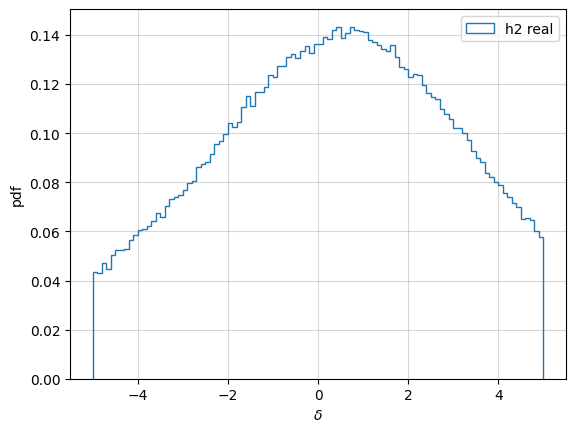

In [30]:
plt.hist(df_h2[abs(df_h2.delta_y5) < 5].delta_y5, bins=100, histtype='step', label='h2 real', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

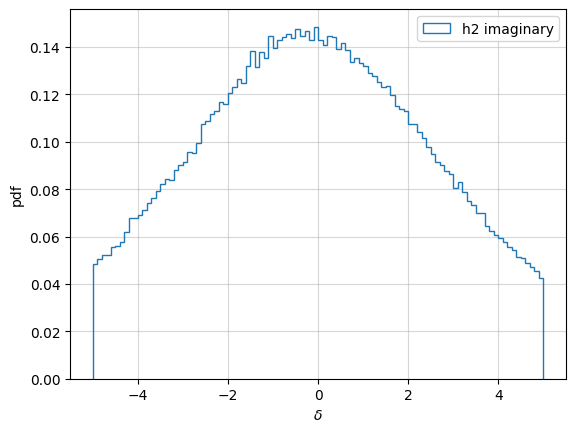

In [31]:
plt.hist(df_h2[abs(df_h2.delta_y6) < 5].delta_y6, bins=100, histtype='step', label='h2 imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

## h4 real and imaginary

In [32]:
df_h4 = pd.read_csv('../models/run6/skip-torch-4D-y13_y14-25424102--16-32-leaky_relu-512-adam-exp-schedule-mse-val_mse-95.625345-99.523986/test-results-25424102-95.625345-99.523986.csv')

In [33]:
df_h4

,Unnamed: 0,x1,x2,x3,x4,y13_scaled,y14_scaled,y13,y14,y13_scaled_pred,y14_scaled_pred,y13_pred,y14_pred,scaled_delta_y13,scaled_delta_y14,delta_y13,delta_y14
0,0,5.434361e-07,0.147431,0.774351,0.245984,-4.845853,4.895268,-126.211720,132.655781,-4.865939,4.915296,-128.792735,135.359637,0.414500,0.409132,2.044989,2.038250
1,1,2.254383e-06,0.705441,0.511854,0.034134,-4.609253,4.697425,-99.409138,108.664476,-4.639852,4.710242,-102.529068,110.079068,0.663865,0.272847,3.138474,1.301798
2,2,3.135050e-06,0.348233,0.460954,0.283262,-5.228611,5.269287,-185.533535,193.277477,-5.182777,5.297554,-177.176903,198.847440,-0.876603,0.536445,-4.504109,2.881848
3,3,3.604113e-06,0.659904,0.123490,0.852356,-2.583237,2.122079,-12.239923,7.348477,-2.744998,2.183359,-14.564587,7.876074,6.261971,2.887744,18.992473,7.179677
4,4,3.774481e-06,0.547915,0.649524,0.693039,-4.921231,4.955359,-136.171432,140.933534,-4.956742,5.027168,-141.130029,151.500503,0.721585,1.449118,3.641437,7.497839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,499707,3.458530e-01,0.084713,0.169534,0.451104,2.064213,1.984650,6.879095,6.276497,2.090844,2.000310,7.091744,6.391345,1.290139,0.789064,3.091233,1.829811
499708,499708,3.460583e-01,0.315792,0.713225,0.709775,2.215834,1.693622,8.169056,4.439148,2.201290,1.670613,8.036662,4.315423,-0.656388,-1.358612,-1.620675,-2.787125
499709,499709,3.465390e-01,0.609794,0.212700,0.336352,2.265060,1.013880,8.631705,1.756275,2.275926,0.988642,8.736927,1.687581,0.479689,-2.489297,1.219011,-3.911330
499710,499710,3.465490e-01,0.432198,0.130247,0.729713,1.917803,1.037826,5.805990,1.823072,1.941075,1.044979,5.966237,1.843337,1.213481,0.689230,2.760039,1.111632


In [34]:
df_h4.describe()

,Unnamed: 0,x1,x2,x3,x4,y13_scaled,y14_scaled,y13,y14,y13_scaled_pred,y14_scaled_pred,y13_pred,y14_pred,scaled_delta_y13,scaled_delta_y14,delta_y13,delta_y14
count,499712.000000,4.997120e+05,499712.000000,499712.000000,4.997120e+05,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000
mean,249855.500000,1.321381e-01,0.499469,0.499598,4.991992e-01,0.746371,2.875462,15.668259,61.278619,0.736502,2.890572,12.195039,57.542000,0.025394,0.535327,1.002772,2.253501
std,144254.573196,2.209283e-01,0.288691,0.288807,2.883081e-01,3.558288,2.622982,339.197844,560.515995,3.560548,2.614688,130.655582,132.446717,414.184796,346.259302,664.113242,676.648332
min,0.000000,6.066240e-10,0.000004,0.000001,1.887156e-09,-11.726637,-7.905152,-123825.551386,-2710.213895,-5.864230,-6.874294,-351.210920,-966.092547,-142424.575732,-21347.523230,-250246.324974,-23547.262373
25%,124927.750000,3.040374e-03,0.249476,0.249090,2.496178e-01,-3.499994,1.842639,-32.115240,5.313175,-3.509237,1.848528,-32.422747,5.350464,-0.714688,-0.448130,-2.455497,-1.556691
50%,249855.500000,2.281552e-02,0.499650,0.499897,4.984394e-01,2.395026,3.732959,9.968478,40.802631,2.393604,3.742149,9.952898,41.188553,0.157672,0.381418,0.553311,1.461202
75%,374783.250000,1.511605e-01,0.749424,0.749368,7.483340e-01,3.241163,4.730649,24.563444,112.369065,3.240744,4.750588,24.552737,114.652273,1.029028,1.106830,3.729972,4.321048
max,499711.000000,9.999568e-01,0.999998,0.999999,9.999981e-01,11.121082,12.635954,67579.982046,307413.961023,7.958180,8.495545,2857.865377,4891.920380,235401.684649,228816.864173,364016.033351,462637.287283


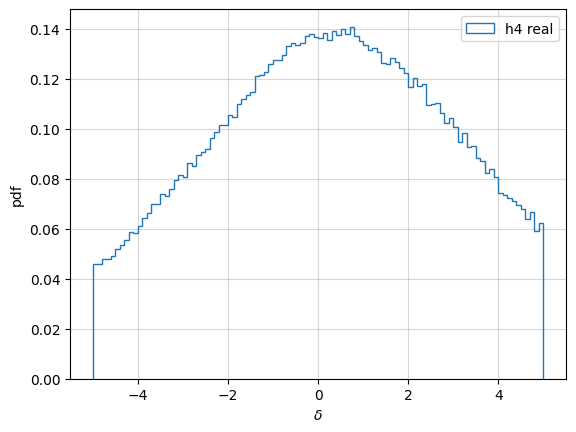

In [35]:
plt.hist(df_h4[abs(df_h4.delta_y13) < 5].delta_y13, bins=100, histtype='step', label='h4 real', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

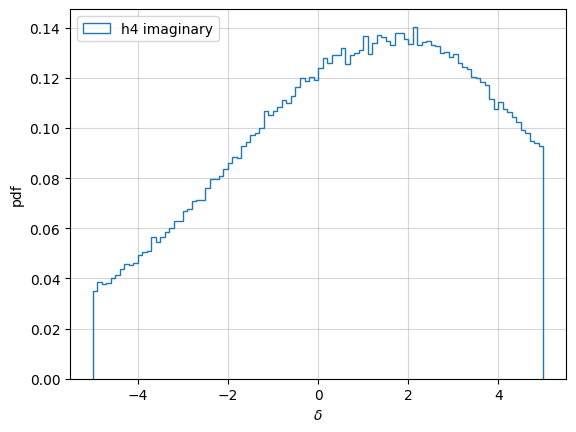

In [74]:
plt.hist(df_h4[abs(df_h4.delta_y14) < 5].delta_y14, bins=100, histtype='step', label='h4 imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

## h2 + h4 real and imaginary

In [37]:
df_h2_plus_h4 = pd.read_csv('../models/run9/skip-torch-4D-y5+y13_y6+y14-37b32f55--16-32-leaky_relu-1024-adam-exp-schedule-mse-val_mse-92.194010-99.687439/test-results-37b32f55-92.194010-99.687439.csv')

In [38]:
df_h2_plus_h4

,Unnamed: 0,x1,x2,x3,x4,y5+y13_scaled,y6+y14_scaled,y5+y13,y6+y14,y5+y13_scaled_pred,y6+y14_scaled_pred,y5+y13_pred,y6+y14_pred,scaled_delta_y5+y13,scaled_delta_y6+y14,delta_y5+y13,delta_y6+y14
0,0,5.434361e-07,0.147431,0.774351,0.245984,-5.709326,5.770255,-300.667662,319.619402,-5.673163,5.767374,-289.953224,318.697204,-0.633410,-0.049919,-3.563549,-0.288530
1,1,2.254383e-06,0.705441,0.511854,0.034134,3.988588,-3.920267,52.978609,-49.413881,3.976036,-3.977601,52.305295,-52.388823,-0.314702,1.462524,-1.270916,6.020457
2,2,3.135050e-06,0.348233,0.460954,0.283262,-4.811306,4.864684,-121.891999,128.629957,-4.774794,4.897167,-117.485886,132.909844,-0.758880,0.667728,-3.614767,3.327286
3,3,3.604113e-06,0.659904,0.123490,0.852356,5.357519,-5.450126,211.197887,-231.787423,5.269550,-5.447742,193.328585,-231.233239,-1.641969,-0.043733,-8.460928,-0.239092
4,4,3.774481e-06,0.547915,0.649524,0.693039,3.581907,-3.627979,34.942011,-36.636665,3.520905,-3.644026,32.815021,-37.245509,-1.703052,0.442324,-6.087200,1.661843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,499707,3.458530e-01,0.084713,0.169534,0.451104,-3.995952,2.075135,-53.377589,6.965623,-4.015327,2.029926,-54.441439,6.613523,0.484871,-2.178610,1.993064,-5.054818
499708,499708,3.460583e-01,0.315792,0.713225,0.709775,-2.072334,0.835396,-6.943338,1.305726,-2.037040,0.790506,-6.667882,1.204511,-1.703066,-5.373480,-3.967205,-7.751616
499709,499709,3.465390e-01,0.609794,0.212700,0.336352,1.069541,-0.624294,1.914042,-0.866927,1.048450,-0.632102,1.853226,-0.881562,-1.971938,1.250746,-3.177337,1.688105
499710,499710,3.465490e-01,0.432198,0.130247,0.729713,-1.847878,-0.964101,-5.346341,-1.622428,-1.812621,-0.956413,-5.126484,-1.602344,-1.907990,-0.797421,-4.112280,-1.237883


In [39]:
df_h2_plus_h4.describe()

,Unnamed: 0,x1,x2,x3,x4,y5+y13_scaled,y6+y14_scaled,y5+y13,y6+y14,y5+y13_scaled_pred,y6+y14_scaled_pred,y5+y13_pred,y6+y14_pred,scaled_delta_y5+y13,scaled_delta_y6+y14,delta_y5+y13,delta_y6+y14
count,499712.000000,4.997120e+05,499712.000000,499712.000000,4.997120e+05,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000
mean,249855.500000,1.321381e-01,0.499469,0.499598,4.991992e-01,-0.005164,-0.000922,-0.587839,-0.144491,-0.004360,-0.001088,-0.800383,-0.789161,-0.445832,-0.818824,0.340867,0.146159
std,144254.573196,2.209283e-01,0.288691,0.288807,2.883081e-01,3.757207,3.547260,423.313959,700.687934,3.758342,3.545774,223.897404,259.511672,258.881642,411.350685,281.918553,554.458452
min,0.000000,6.066240e-10,0.000004,0.000001,1.887156e-09,-11.724472,-11.666425,-123557.713364,-116589.756017,-9.472080,-10.235653,-12990.888305,-27878.671639,-103377.142905,-109196.746527,-113763.974291,-109468.750084
25%,124927.750000,3.040374e-03,0.249476,0.249090,2.496178e-01,-3.427783,-3.058063,-29.808251,-20.286285,-3.432437,-3.062290,-29.951984,-20.376463,-0.891806,-1.245860,-3.165378,-4.014872
50%,249855.500000,2.281552e-02,0.499650,0.499897,4.984394e-01,-0.033836,-0.001100,-0.034415,-0.001100,-0.047234,-0.000889,-0.048367,-0.000889,0.211549,0.059267,0.798396,0.230060
75%,374783.250000,1.511605e-01,0.749424,0.749368,7.483340e-01,3.419319,3.056266,29.548603,20.248063,3.437689,3.056512,30.114961,20.253297,1.344445,1.422271,4.868312,4.664941
max,499711.000000,9.999568e-01,0.999998,0.999999,9.999981e-01,11.122507,12.636475,67676.391029,307574.181434,9.042874,9.484533,8457.049524,13153.676085,117573.615061,159155.385937,125578.892385,286661.657598


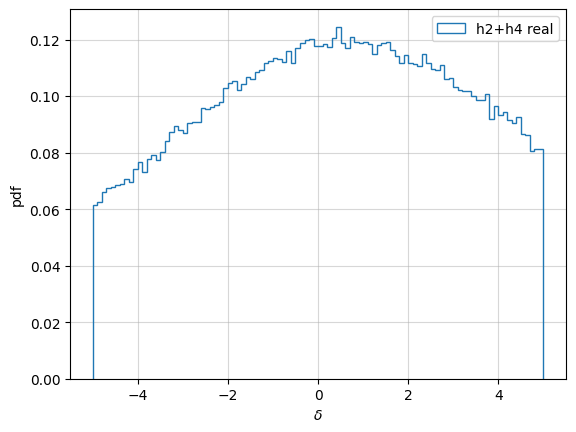

In [77]:
plt.hist(df_h2_plus_h4[abs(df_h2_plus_h4['delta_y5+y13']) < 5]['delta_y5+y13'], bins=100, histtype='step', label='h2+h4 real', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

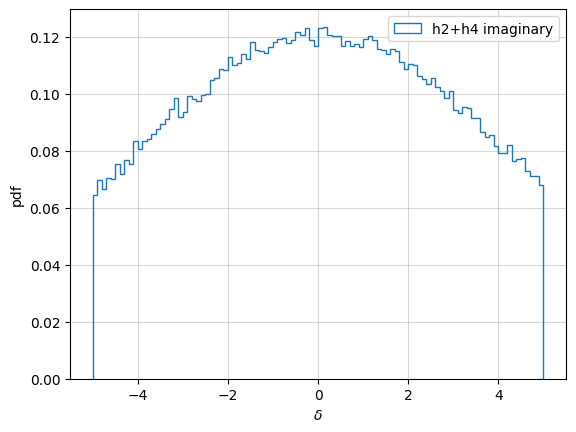

In [79]:
plt.hist(df_h2_plus_h4[abs(df_h2_plus_h4['delta_y6+y14']) < 5]['delta_y6+y14'], bins=100, histtype='step', label='h2+h4 imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

## h2 - h4 real and imaginary

In [42]:
df_h2_minus_h4 = pd.read_csv('../models/run11/skip-torch-4D-y5-y13_y6-y14-583ead07--16-32-leaky_relu-1024-adam-exp-schedule-mse-val_mse-97.420125-99.715115/test-results-583ead07-97.420125-99.715115.csv')

In [43]:
df_h2_minus_h4

,Unnamed: 0,x1,x2,x3,x4,y5-y13_scaled,y6-y14_scaled,y5-y13,y6-y14,y5-y13_scaled_pred,y6-y14_scaled_pred,y5-y13_pred,y6-y14_pred,scaled_delta_y5-y13,scaled_delta_y6-y14,delta_y5-y13,delta_y6-y14
0,0,5.434361e-07,0.147431,0.774351,0.245984,-3.896792,4.012915,-48.244223,54.307841,-3.758316,3.922234,-41.876183,49.513146,-3.553579,-2.259731,-13.199592,-8.828734
1,1,2.254383e-06,0.705441,0.511854,0.034134,5.532586,-5.590027,251.796884,-266.742834,5.494788,-5.581389,242.419929,-264.439932,-0.683194,-0.154532,-3.724016,-0.863342
2,2,3.135050e-06,0.348233,0.460954,0.283262,5.522161,-5.556538,249.175071,-257.924998,5.512050,-5.525276,246.658319,-249.955653,-0.183097,-0.562620,-1.010034,-3.089791
3,3,3.604113e-06,0.659904,0.123490,0.852356,5.466699,-5.511347,235.677733,-246.484377,5.363745,-5.482611,212.523127,-239.473849,-1.883299,-0.521399,-9.824690,-2.844208
4,4,3.774481e-06,0.547915,0.649524,0.693039,5.731024,-5.766769,307.284875,-318.503732,5.737745,-5.788621,309.363663,-325.562373,0.117264,0.378930,0.676502,2.216188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,499707,3.458530e-01,0.084713,0.169534,0.451104,-4.221502,-1.885154,-67.135780,-5.587371,-4.195292,-1.923575,-65.373100,-5.845386,-0.620884,2.038056,-2.625546,4.617823
499708,499708,3.460583e-01,0.315792,0.713225,0.709775,-3.189713,-2.148567,-23.281449,-7.572569,-3.195317,-2.197807,-23.417907,-8.005241,0.175693,2.291724,0.586123,5.713670
499709,499709,3.465390e-01,0.609794,0.212700,0.336352,-2.794189,-1.682591,-15.349369,-4.379476,-2.777828,-1.653501,-15.084042,-4.225239,-0.585562,-1.728906,-1.728585,-3.521812
499710,499710,3.465490e-01,0.432198,0.130247,0.729713,-2.888054,-1.835548,-16.958321,-5.268571,-2.883111,-1.839834,-16.869778,-5.295492,-0.171142,0.233472,-0.522121,0.510983


In [44]:
df_h2_minus_h4.describe()

,Unnamed: 0,x1,x2,x3,x4,y5-y13_scaled,y6-y14_scaled,y5-y13,y6-y14,y5-y13_scaled_pred,y6-y14_scaled_pred,y5-y13_pred,y6-y14_pred,scaled_delta_y5-y13,scaled_delta_y6-y14,delta_y5-y13,delta_y6-y14
count,499712.000000,4.997120e+05,499712.000000,499712.000000,4.997120e+05,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000
mean,249855.500000,1.321381e-01,0.499469,0.499598,4.991992e-01,-1.219272,-3.375268,-31.924358,-122.701729,-1.223385,-3.375314,-29.717846,-117.078474,-0.338736,-0.068386,-0.417418,0.468715
std,144254.573196,2.209283e-01,0.288691,0.288807,2.883081e-01,4.096335,2.903235,415.962739,709.992914,4.091122,2.903088,233.040088,292.189818,99.493194,236.794626,410.407310,275.177366
min,0.000000,6.066240e-10,0.000004,0.000001,1.887156e-09,-11.119654,-12.635432,-67483.573063,-307253.740613,-10.050745,-10.440990,-23172.046449,-34233.543416,-45525.795316,-99162.252513,-277517.149692,-104782.392802
25%,124927.750000,3.040374e-03,0.249476,0.249090,2.496178e-01,-4.119042,-5.379849,-60.500301,-215.989602,-4.118840,-5.378642,-60.487892,-215.727797,-0.654624,-0.623957,-2.760043,-2.594317
50%,249855.500000,2.281552e-02,0.499650,0.499897,4.984394e-01,-3.350736,-4.396246,-27.523729,-80.145670,-3.353871,-4.407216,-27.613292,-81.040711,0.018704,0.016853,0.077352,0.075230
75%,374783.250000,1.511605e-01,0.749424,0.749368,7.483340e-01,4.069867,-2.338755,57.549188,-9.368320,4.061342,-2.339372,57.052158,-9.374722,0.692295,0.668314,2.885846,2.815942
max,499711.000000,9.999568e-01,0.999998,0.999999,9.999981e-01,11.728798,7.902728,124093.389408,2703.650920,9.939271,8.627107,20727.630365,5579.910830,35636.688977,115675.726717,46681.744738,136945.097785


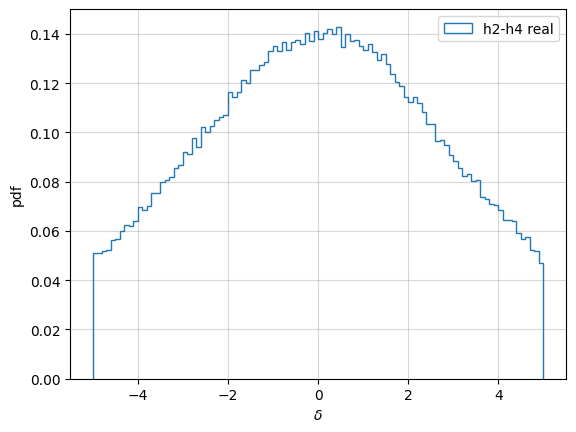

In [45]:
plt.hist(df_h2_minus_h4[abs(df_h2_minus_h4['delta_y5-y13']) < 5]['delta_y5-y13'], bins=100, histtype='step', label='h2-h4 real', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

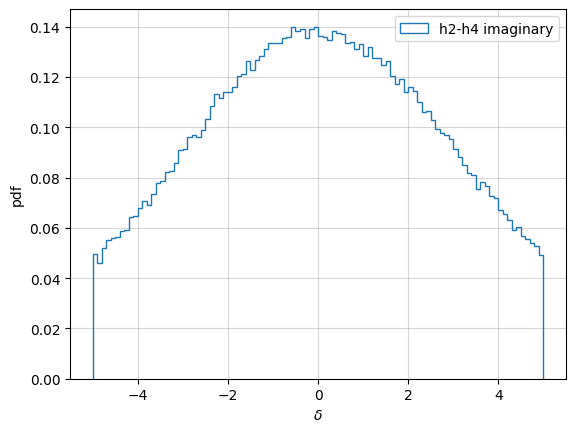

In [46]:
plt.hist(df_h2_minus_h4[abs(df_h2_minus_h4['delta_y6-y14']) < 5]['delta_y6-y14'], bins=100, histtype='step', label='h2-h4 imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

## Combining all dataframes, h2, h4, h2+h4, h2-h4

In [47]:
df_all["y5+y13"] = df_h2_plus_h4["y5+y13_pred"]
df_all["y6+y14"] = df_h2_plus_h4["y6+y14_pred"]

In [48]:
df_all["y5-y13"] = df_h2_minus_h4["y5-y13_pred"]
df_all["y6-y14"] = df_h2_minus_h4["y6-y14_pred"]

In [49]:
df = df_all.copy(deep=True)

In [50]:
df["y5_calc"] = (df["y5+y13"] + df["y5-y13"])/2
df["y13_calc"] = (df["y5+y13"] - df["y5-y13"])/2

In [51]:
df["y6_calc"] = (df["y6+y14"] + df["y6-y14"])/2
df["y14_calc"] = (df["y6+y14"] - df["y6-y14"])/2

In [52]:
df

,x1,x2,x3,x4,y5,y6,y13,y14,y5+y13,y6+y14,y5-y13,y6-y14,y5_calc,y13_calc,y6_calc,y14_calc
0,5.434361e-07,0.147431,0.774351,0.245984,-174.455943,186.963621,-126.211720,132.655781,-289.953224,318.697204,-41.876183,49.513146,-165.914703,-124.038521,184.105175,134.592029
1,2.254383e-06,0.705441,0.511854,0.034134,152.387746,-158.078358,-99.409138,108.664476,52.305295,-52.388823,242.419929,-264.439932,147.362612,-95.057317,-158.414377,106.025554
2,3.135050e-06,0.348233,0.460954,0.283262,63.641536,-64.647520,-185.533535,193.277477,-117.485886,132.909844,246.658319,-249.955653,64.586217,-182.072103,-58.522905,191.432749
3,3.604113e-06,0.659904,0.123490,0.852356,223.437810,-239.135900,-12.239923,7.348477,193.328585,-231.233239,212.523127,-239.473849,202.925856,-9.597271,-235.353544,4.120305
4,3.774481e-06,0.547915,0.649524,0.693039,171.113443,-177.570199,-136.171432,140.933534,32.815021,-37.245509,309.363663,-325.562373,171.089342,-138.274321,-181.403941,144.158432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,3.458530e-01,0.084713,0.169534,0.451104,-60.256685,0.689126,6.879095,6.276497,-54.441439,6.613523,-65.373100,-5.845386,-59.907269,5.465831,0.384069,6.229455
499708,3.460583e-01,0.315792,0.713225,0.709775,-15.112394,-3.133422,8.169056,4.439148,-6.667882,1.204511,-23.417907,-8.005241,-15.042894,8.375013,-3.400365,4.604876
499709,3.465390e-01,0.609794,0.212700,0.336352,-6.717664,-2.623202,8.631705,1.756275,1.853226,-0.881562,-15.084042,-4.225239,-6.615408,8.468634,-2.553400,1.671839
499710,3.465490e-01,0.432198,0.130247,0.729713,-11.152331,-3.445499,5.805990,1.823072,-5.126484,-1.602344,-16.869778,-5.295492,-10.998131,5.871647,-3.448918,1.846574


In [53]:
y5_calc = df["y5_calc"]
y6_calc = df["y6_calc"]
y13_calc = df["y13_calc"]
y14_calc = df["y14_calc"]
y5 = df["y5"]
y6 = df["y6"]
y13 = df["y13"]
y14 = df["y14"]

In [54]:
#df = dfb
dfb = df.copy(deep = True)

In [55]:
df = pd.concat([df, pd.DataFrame((y5_calc - y5)/y5*100, columns=["delta_y5"])], axis=1)
df = pd.concat([df, pd.DataFrame((y13_calc - y13)/y13*100, columns=["delta_y13"])], axis=1)
df = pd.concat([df, pd.DataFrame((y6_calc - y6)/y6*100, columns=["delta_y6"])], axis=1)
df = pd.concat([df, pd.DataFrame((y14_calc - y14)/y14*100, columns=["delta_y14"])], axis=1)

In [56]:
df

,x1,x2,x3,x4,y5,y6,y13,y14,y5+y13,y6+y14,y5-y13,y6-y14,y5_calc,y13_calc,y6_calc,y14_calc,delta_y5,delta_y13,delta_y6,delta_y14
0,5.434361e-07,0.147431,0.774351,0.245984,-174.455943,186.963621,-126.211720,132.655781,-289.953224,318.697204,-41.876183,49.513146,-165.914703,-124.038521,184.105175,134.592029,-4.895929,-1.721868,-1.528878,1.459603
1,2.254383e-06,0.705441,0.511854,0.034134,152.387746,-158.078358,-99.409138,108.664476,52.305295,-52.388823,242.419929,-264.439932,147.362612,-95.057317,-158.414377,106.025554,-3.297598,-4.377687,0.212565,-2.428505
2,3.135050e-06,0.348233,0.460954,0.283262,63.641536,-64.647520,-185.533535,193.277477,-117.485886,132.909844,246.658319,-249.955653,64.586217,-182.072103,-58.522905,191.432749,1.484377,-1.865664,-9.473860,-0.954446
3,3.604113e-06,0.659904,0.123490,0.852356,223.437810,-239.135900,-12.239923,7.348477,193.328585,-231.233239,212.523127,-239.473849,202.925856,-9.597271,-235.353544,4.120305,-9.180162,-21.590430,-1.581677,-43.929809
4,3.774481e-06,0.547915,0.649524,0.693039,171.113443,-177.570199,-136.171432,140.933534,32.815021,-37.245509,309.363663,-325.562373,171.089342,-138.274321,-181.403941,144.158432,-0.014085,1.544295,2.159001,2.288240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,3.458530e-01,0.084713,0.169534,0.451104,-60.256685,0.689126,6.879095,6.276497,-54.441439,6.613523,-65.373100,-5.845386,-59.907269,5.465831,0.384069,6.229455,-0.579879,-20.544343,-44.267280,-0.749500
499708,3.460583e-01,0.315792,0.713225,0.709775,-15.112394,-3.133422,8.169056,4.439148,-6.667882,1.204511,-23.417907,-8.005241,-15.042894,8.375013,-3.400365,4.604876,-0.459883,2.521187,8.519225,3.733338
499709,3.465390e-01,0.609794,0.212700,0.336352,-6.717664,-2.623202,8.631705,1.756275,1.853226,-0.881562,-15.084042,-4.225239,-6.615408,8.468634,-2.553400,1.671839,-1.522191,-1.889213,-2.660914,-4.807664
499710,3.465490e-01,0.432198,0.130247,0.729713,-11.152331,-3.445499,5.805990,1.823072,-5.126484,-1.602344,-16.869778,-5.295492,-10.998131,5.871647,-3.448918,1.846574,-1.382668,1.130845,0.099227,1.289178


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499712 entries, 0 to 499711
Data columns (total 20 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   x1         499712 non-null  float64
 1   x2         499712 non-null  float64
 2   x3         499712 non-null  float64
 3   x4         499712 non-null  float64
 4   y5         499712 non-null  float64
 5   y6         499712 non-null  float64
 6   y13        499712 non-null  float64
 7   y14        499712 non-null  float64
 8   y5+y13     499712 non-null  float64
 9   y6+y14     499712 non-null  float64
 10  y5-y13     499712 non-null  float64
 11  y6-y14     499712 non-null  float64
 12  y5_calc    499712 non-null  float64
 13  y13_calc   499712 non-null  float64
 14  y6_calc    499712 non-null  float64
 15  y14_calc   499712 non-null  float64
 16  delta_y5   499712 non-null  float64
 17  delta_y13  499712 non-null  float64
 18  delta_y6   499712 non-null  float64
 19  delta_y14  499712 non-n

In [57]:
cfg = {}
cfg["var_y"] = ["y5", "y13", "y6", "y14"]
cfg['input_shape'] = 4
num_vars = len(cfg['var_y'])
base_length = cfg['input_shape'] + num_vars

In [58]:
df

,x1,x2,x3,x4,y5,y6,y13,y14,y5+y13,y6+y14,y5-y13,y6-y14,y5_calc,y13_calc,y6_calc,y14_calc,delta_y5,delta_y13,delta_y6,delta_y14
0,5.434361e-07,0.147431,0.774351,0.245984,-174.455943,186.963621,-126.211720,132.655781,-289.953224,318.697204,-41.876183,49.513146,-165.914703,-124.038521,184.105175,134.592029,-4.895929,-1.721868,-1.528878,1.459603
1,2.254383e-06,0.705441,0.511854,0.034134,152.387746,-158.078358,-99.409138,108.664476,52.305295,-52.388823,242.419929,-264.439932,147.362612,-95.057317,-158.414377,106.025554,-3.297598,-4.377687,0.212565,-2.428505
2,3.135050e-06,0.348233,0.460954,0.283262,63.641536,-64.647520,-185.533535,193.277477,-117.485886,132.909844,246.658319,-249.955653,64.586217,-182.072103,-58.522905,191.432749,1.484377,-1.865664,-9.473860,-0.954446
3,3.604113e-06,0.659904,0.123490,0.852356,223.437810,-239.135900,-12.239923,7.348477,193.328585,-231.233239,212.523127,-239.473849,202.925856,-9.597271,-235.353544,4.120305,-9.180162,-21.590430,-1.581677,-43.929809
4,3.774481e-06,0.547915,0.649524,0.693039,171.113443,-177.570199,-136.171432,140.933534,32.815021,-37.245509,309.363663,-325.562373,171.089342,-138.274321,-181.403941,144.158432,-0.014085,1.544295,2.159001,2.288240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,3.458530e-01,0.084713,0.169534,0.451104,-60.256685,0.689126,6.879095,6.276497,-54.441439,6.613523,-65.373100,-5.845386,-59.907269,5.465831,0.384069,6.229455,-0.579879,-20.544343,-44.267280,-0.749500
499708,3.460583e-01,0.315792,0.713225,0.709775,-15.112394,-3.133422,8.169056,4.439148,-6.667882,1.204511,-23.417907,-8.005241,-15.042894,8.375013,-3.400365,4.604876,-0.459883,2.521187,8.519225,3.733338
499709,3.465390e-01,0.609794,0.212700,0.336352,-6.717664,-2.623202,8.631705,1.756275,1.853226,-0.881562,-15.084042,-4.225239,-6.615408,8.468634,-2.553400,1.671839,-1.522191,-1.889213,-2.660914,-4.807664
499710,3.465490e-01,0.432198,0.130247,0.729713,-11.152331,-3.445499,5.805990,1.823072,-5.126484,-1.602344,-16.869778,-5.295492,-10.998131,5.871647,-3.448918,1.846574,-1.382668,1.130845,0.099227,1.289178


In [59]:
from sklearn import metrics
import numpy as np

In [60]:
cfg['test_metrics'] = {}
cfg['test_metrics']['r2'] = {}
cfg['test_metrics']['abs_score'] = {}

In [61]:
for var in cfg["var_y"]:
    test = df[var].values
    pred = df[var+'_calc'].values
    cfg['test_metrics']['r2'][var] = metrics.r2_score(test, pred)*100
    cfg['test_metrics']['abs_score'][var] = 100 - np.abs(df['delta_'+var].mean())

In [62]:
cfg

{'var_y': ['y5', 'y13', 'y6', 'y14'],
 'input_shape': 4,
 'test_metrics': {'r2': {'y5': 57.75528791079175,
   'y13': 24.08839663367163,
   'y6': 37.51870295182249,
   'y14': 11.928114059947426},
  'abs_score': {'y5': 30.924643789707645,
   'y13': 93.77642124853502,
   'y6': 85.67339712243107,
   'y14': 99.22523617171936}}}

In [83]:
# Calculate R2 scores for each of y5, y6, y13, and y14
r2_y5 = metrics.r2_score(df['y5'], df['y5_calc'])
r2_y6 = metrics.r2_score(df['y6'], df['y6_calc'])
r2_y13 = metrics.r2_score(df['y13'], df['y13_calc'])
r2_y14 = metrics.r2_score(df['y14'], df['y14_calc'])

# Calculate abs_score for each of y5, y6, y13, and y14
abs_score_y5 = (1 - np.mean(np.abs((df['y5_calc'] - df['y5']) / df['y5']))) * 100
abs_score_y6 = (1 - np.mean(np.abs((df['y6_calc'] - df['y6']) / df['y6']))) * 100
abs_score_y13 = (1 - np.mean(np.abs((df['y13_calc'] - df['y13']) / df['y13']))) * 100
abs_score_y14 = (1 - np.mean(np.abs((df['y14_calc'] - df['y14']) / df['y14']))) * 100

# Return the results
r2_scores = {
    'r2_y5': r2_y5,
    'r2_y6': r2_y6,
    'r2_y13': r2_y13,
    'r2_y14': r2_y14,
}

abs_scores = {
    'abs_score_y5': abs_score_y5,
    'abs_score_y6': abs_score_y6,
    'abs_score_y13': abs_score_y13,
    'abs_score_y14': abs_score_y14,
}

r2_scores, abs_scores

({'r2_y5': 0.5775528791079175,
  'r2_y6': 0.3751870295182249,
  'r2_y13': 0.24088396633671627,
  'r2_y14': 0.11928114059947426},
 {'abs_score_y5': -20.636996965190857,
  'abs_score_y6': 66.83588554295189,
  'abs_score_y13': 55.615001081598606,
  'abs_score_y14': 75.81415604783537})

## h2 real and imaginary

In [109]:
df

,x1,x2,x3,x4,y5,y6,y13,y14,y5+y13,y6+y14,y5-y13,y6-y14,y5_calc,y13_calc,y6_calc,y14_calc,delta_y5,delta_y13,delta_y6,delta_y14
0,5.434361e-07,0.147431,0.774351,0.245984,-174.455943,186.963621,-126.211720,132.655781,-289.953224,318.697204,-41.876183,49.513146,-165.914703,-124.038521,184.105175,134.592029,-4.895929,-1.721868,-1.528878,1.459603
1,2.254383e-06,0.705441,0.511854,0.034134,152.387746,-158.078358,-99.409138,108.664476,52.305295,-52.388823,242.419929,-264.439932,147.362612,-95.057317,-158.414377,106.025554,-3.297598,-4.377687,0.212565,-2.428505
2,3.135050e-06,0.348233,0.460954,0.283262,63.641536,-64.647520,-185.533535,193.277477,-117.485886,132.909844,246.658319,-249.955653,64.586217,-182.072103,-58.522905,191.432749,1.484377,-1.865664,-9.473860,-0.954446
3,3.604113e-06,0.659904,0.123490,0.852356,223.437810,-239.135900,-12.239923,7.348477,193.328585,-231.233239,212.523127,-239.473849,202.925856,-9.597271,-235.353544,4.120305,-9.180162,-21.590430,-1.581677,-43.929809
4,3.774481e-06,0.547915,0.649524,0.693039,171.113443,-177.570199,-136.171432,140.933534,32.815021,-37.245509,309.363663,-325.562373,171.089342,-138.274321,-181.403941,144.158432,-0.014085,1.544295,2.159001,2.288240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,3.458530e-01,0.084713,0.169534,0.451104,-60.256685,0.689126,6.879095,6.276497,-54.441439,6.613523,-65.373100,-5.845386,-59.907269,5.465831,0.384069,6.229455,-0.579879,-20.544343,-44.267280,-0.749500
499708,3.460583e-01,0.315792,0.713225,0.709775,-15.112394,-3.133422,8.169056,4.439148,-6.667882,1.204511,-23.417907,-8.005241,-15.042894,8.375013,-3.400365,4.604876,-0.459883,2.521187,8.519225,3.733338
499709,3.465390e-01,0.609794,0.212700,0.336352,-6.717664,-2.623202,8.631705,1.756275,1.853226,-0.881562,-15.084042,-4.225239,-6.615408,8.468634,-2.553400,1.671839,-1.522191,-1.889213,-2.660914,-4.807664
499710,3.465490e-01,0.432198,0.130247,0.729713,-11.152331,-3.445499,5.805990,1.823072,-5.126484,-1.602344,-16.869778,-5.295492,-10.998131,5.871647,-3.448918,1.846574,-1.382668,1.130845,0.099227,1.289178


In [110]:
df.describe()

,x1,x2,x3,x4,y5,y6,y13,y14,y5+y13,y6+y14,y5-y13,y6-y14,y5_calc,y13_calc,y6_calc,y14_calc,delta_y5,delta_y13,delta_y6,delta_y14
count,4.997120e+05,499712.000000,499712.000000,4.997120e+05,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,499712.000000,4.997120e+05,4.997120e+05,4.997120e+05,4.997120e+05
mean,1.321381e-01,0.499469,0.499598,4.991992e-01,-16.256098,-61.423110,15.668259,61.278619,-0.800383,-0.789161,-29.717846,-117.078474,-15.259115,14.458731,-58.933817,58.144657,-6.907536e+01,-6.223579e+00,1.432660e+01,-7.747638e-01
std,2.209283e-01,0.288691,0.288807,2.883081e-01,247.092445,428.192222,339.197844,560.515995,223.897404,259.511672,233.040088,292.189818,169.604152,153.144692,217.797013,170.073690,5.434674e+04,5.656950e+03,9.135126e+03,3.278061e+03
min,6.066240e-10,0.000004,0.000001,1.887156e-09,-48411.017079,-116564.245685,-123825.551386,-2710.213895,-12990.888305,-27878.671639,-23172.046449,-34233.543416,-9990.935567,-10602.658595,-31056.107528,-8675.251785,-3.833517e+07,-3.568796e+06,-5.122709e+05,-1.029807e+06
25%,3.040374e-03,0.249476,0.249090,2.496178e-01,-24.849805,-112.594545,-32.115240,5.313175,-29.951984,-20.376463,-60.487892,-215.727797,-25.972622,-31.304389,-112.183870,5.179154,-2.888620e+00,-3.219439e+00,-2.785543e+00,-2.876238e+00
50%,2.281552e-02,0.499650,0.499897,4.984394e-01,-10.024829,-40.683500,9.968478,40.802631,-0.048367,-0.000889,-27.613292,-81.040711,-10.071202,10.020776,-40.162248,40.566295,3.325188e-01,1.073421e-01,1.377497e-01,-5.247296e-03
75%,1.511605e-01,0.749424,0.749368,7.483340e-01,31.870417,-5.234014,24.563444,112.369065,30.114961,20.253297,57.052158,-9.374722,32.158352,25.732673,-5.069514,112.348930,3.487723e+00,3.296049e+00,3.054337e+00,2.881421e+00
max,9.999568e-01,0.999998,0.999999,9.999981e-01,25628.215377,2429.490484,67579.982046,307413.961023,8457.049524,13153.676085,20727.630365,5579.910830,10124.971770,13181.110883,4687.819750,9500.246848,2.062626e+06,1.307724e+06,6.134498e+06,1.945168e+06


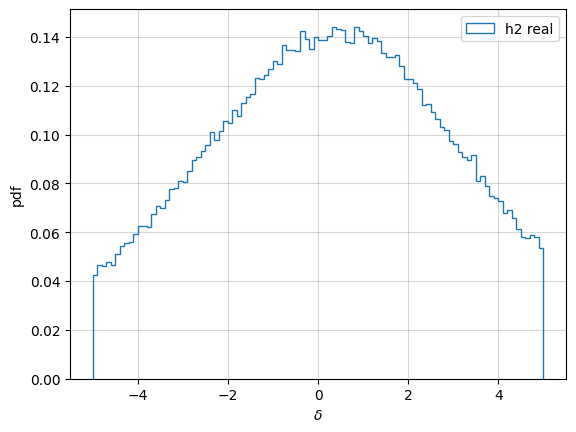

In [111]:
plt.hist(df[abs(df.delta_y5) < 5].delta_y5, bins=100, histtype='step', label='h2 real', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

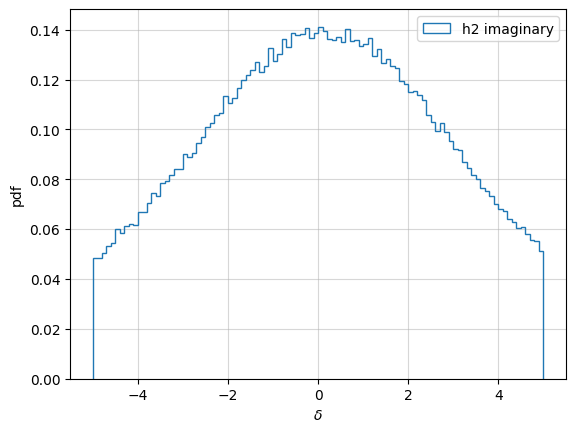

In [112]:
plt.hist(df[abs(df.delta_y6) < 5].delta_y6, bins=100, histtype='step', label='h2 imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

## h4 real and imaginary

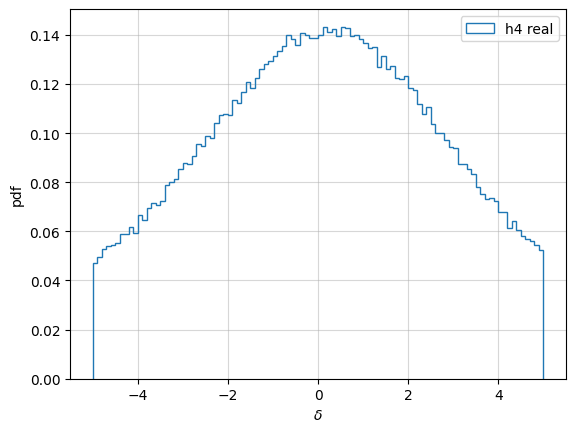

In [113]:
plt.hist(df[abs(df.delta_y13) < 5].delta_y13, bins=100, histtype='step', label='h4 real', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()

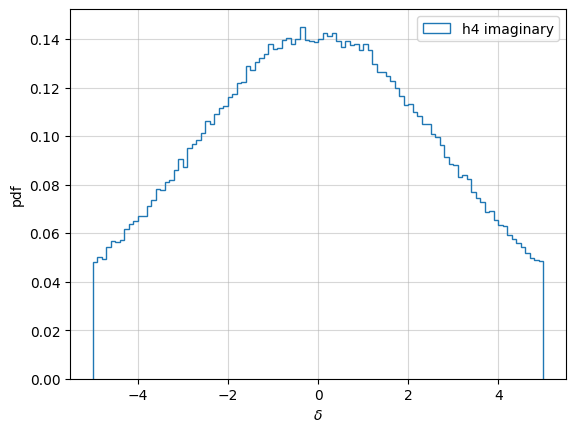

In [114]:
plt.hist(df[abs(df.delta_y14) < 5].delta_y14, bins=100, histtype='step', label='h4 imaginary', density=True)
plt.grid('dotted', alpha=0.5)
plt.xlabel(r'$\delta$')
plt.ylabel(r'pdf')
plt.legend()
plt.show()